# import libraries

In [45]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score

In [15]:
#load dataset

df=pd.read_csv('novagen_dataset.csv')

In [16]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [18]:
df.columns

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='object')

In [19]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

In [27]:
incoded_cols=[ 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O']

for cols in incoded_cols:
    df[cols]=le.fit_transform(df[cols])

In [28]:
df.shape

(9549, 23)

In [29]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,0,1,1,0,0
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,0,0,1,0,0
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,1,0,0,0,0
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,1,0,0,1,0
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,0,1,0,1,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [38]:
df['Target'].value_counts()

Target
1    4979
0    4570
Name: count, dtype: int64

<Figure size 700x800 with 0 Axes>

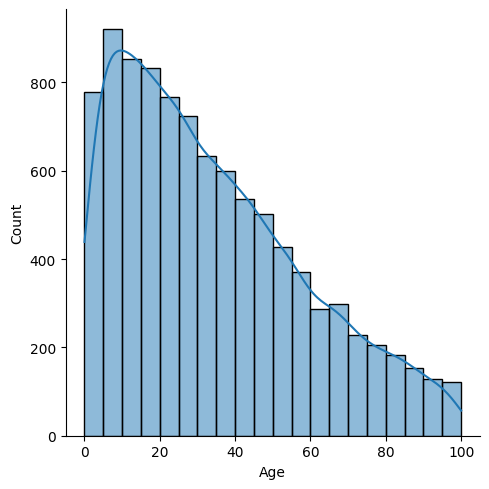

In [42]:
plt.figure(figsize=(7,8))
sns.displot(data=df,x='Age',kde=True,bins=20)

In [43]:
df['Age'].mean()

np.float64(33.80678605089538)

In [47]:
#train test split 

X=df.drop('Target',axis=1)
y=df['Target']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.20, random_state=42)

# Decision tree model 

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [69]:
#decison tree model 

dt=DecisionTreeClassifier(max_depth=7)

dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [70]:
y_pred=dt.predict(X_test)

y_pred

array([0, 1, 0, ..., 1, 1, 1], shape=(1910,))

In [71]:
#accuracy on decison treversed

print("accuracy on training data",accuracy_score(y_train,dt.predict(X_train)))
print("accuracy on testing data",accuracy_score(y_test,y_pred))

accuracy on training data 0.9007723524021469
accuracy on testing data 0.8905759162303665


# logistic regression

In [59]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=4000)
lr.fit(X_test,y_test)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,4000
,multi_class,'deprecated'


In [62]:
#accuracy on logistic regrission

print("accuracy on training data",accuracy_score(y_train,lr.predict(X_train)))
print("accuracy on testing data",accuracy_score(y_test,lr.predict(X_test)))

accuracy on training data 0.8092682288257625
accuracy on testing data 0.8277486910994765


# Gradient Boosting algorithms

In [96]:
from sklearn.ensemble import GradientBoostingClassifier

gbc=GradientBoostingClassifier(n_estimators=150,learning_rate=0.1,random_state=42,max_depth=3)

gbc.fit(X_test,y_test)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [97]:
#accuracy on Gradient boosting classifier

print("accuracy on training data",accuracy_score(y_train,lr.predict(X_train)))
print("accuracy on testing data",accuracy_score(y_test,lr.predict(X_test)))

accuracy on training data 0.8092682288257625
accuracy on testing data 0.8277486910994765


## Ada boost

In [94]:
from sklearn.ensemble import AdaBoostClassifier

adc=AdaBoostClassifier(n_estimators=500,learning_rate=0.1,random_state=42,estimator=dt)

adc.fit(X_test,y_test)

,estimator,DecisionTreeC...r(max_depth=7)
,n_estimators,500
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [95]:
#accuracy on Adaptive boosting classifier

print("accuracy on training data",accuracy_score(y_train,adc.predict(X_train)))
print("accuracy on testing data",accuracy_score(y_test,adc.predict(X_test)))

accuracy on training data 0.9317973556748266
accuracy on testing data 1.0
